
# 📊 Visualizing 3D Point Clouds with Open3D

This script allows you to **load and visualize `.ply` point cloud files** from the [ModelNet40](https://modelnet.cs.princeton.edu/) dataset (or similar datasets). It uses the [Open3D](http://www.open3d.org/) library to render 3D objects interactively in a viewer window.

---

## 📁 Dataset Structure

The directory is expected to be organized by category, like below:

```

ModelNet40\_PointE/
├── bathtub/
│   ├── bathtub\_0001.ply
│   └── ...
├── chair/
├── bench/
└── car/

````

---

## 🧪 What This Script Does

1. **Load a single point cloud file** and visualize it.
2. **Randomly sample and display** 1–2 `.ply` files per class from selected categories (e.g., `"bench"`, `"chair"`, `"car"`).

---

## 📜 Code Overview

```python
# Load and visualize a single .ply file
pcd = o3d.io.read_point_cloud(file_path)
o3d.visualization.draw_geometries([pcd])

# Iterate over selected classes and visualize a few random samples
for cls in target_classes:
    ply_files = [...]
    for f in random.sample(ply_files, min(2, len(ply_files))):
        pcd = o3d.io.read_point_cloud(...)
        o3d.visualization.draw_geometries([pcd])
````

---

## 🖥️ Requirements

Install Open3D via pip if you haven't already:

```bash
pip install open3d
```

---

## ✅ How to Run

1. Update the `base_dir` and `target_classes` in the script to match your dataset location.
2. Run the script:

   ```bash
   python visualize_pointclouds.py
   ```
3. Each sample will be shown in an interactive Open3D 3D viewer.

---

## 🔍 Tips

* You can adjust the number of visualized samples by modifying `min(2, len(ply_files))`.
* This script can be extended to support `.off` or `.xyz` formats by replacing the `read_point_cloud()` logic.

---

## 🧠 Use Cases

* Verifying the quality of generated or augmented 3D data.
* Visual inspection of class balance or diversity.
* Preparing demo or presentation visuals for 3D datasets.

```




In [1]:
import os
import open3d as o3d
import random

# 🔹 Set the file path (Mac local path used here)
file_path = "/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE/bathtub/bathtub_0001.ply"

# 🔹 Load the point cloud
pcd = o3d.io.read_point_cloud(file_path)

# 🔹 Visualize the point cloud (opens a 3D viewer window)
o3d.visualization.draw_geometries([pcd])

# 🔹 Base directory and selected target classes to visualize
base_dir = "/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE"
target_classes = ["bench", "chair", "car"]  # Select the object categories you want to visualize

# 🔹 Iterate over the selected classes and visualize a few samples
for cls in target_classes:
    class_path = os.path.join(base_dir, cls)
    ply_files = [f for f in os.listdir(class_path) if f.endswith('.ply')]

    # Randomly display 1 or 2 samples from each class
    for f in random.sample(ply_files, min(2, len(ply_files))):
        file_path = os.path.join(class_path, f)
        print(f"Showing: {file_path}")
        pcd = o3d.io.read_point_cloud(file_path)
        o3d.visualization.draw_geometries([pcd])


Showing: /Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE/bench/bench_0002.ply
Showing: /Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE/bench/bench_0012.ply
Showing: /Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE/chair/chair_0010.ply
Showing: /Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE/chair/chair_0018.ply
Showing: /Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE/car/car_0019.ply


KeyboardInterrupt: 

In [ ]:
import os
import open3d as o3d
import random

# 🔹 Base directory and target classes
base_dir = "/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/ModelNet40_PointE"
target_classes = ["bench", "chair", "car"]  # 원하는 클래스

# 🔹 Iterate through each class and show exactly 2 random samples
for cls in target_classes:
    class_path = os.path.join(base_dir, cls)
    ply_files = [f for f in os.listdir(class_path) if f.endswith('.ply')]

    if len(ply_files) < 2:
        print(f"Warning: {cls} class has less than 2 samples. Showing available samples only.")
        sample_files = ply_files  # 1개 또는 없음
    else:
        sample_files = random.sample(ply_files, 2)  # 정확히 2개 선택

    for f in sample_files:
        file_path = os.path.join(class_path, f)
        print(f"Showing: {file_path}")
        pcd = o3d.io.read_point_cloud(file_path)
        o3d.visualization.draw_geometries([pcd])


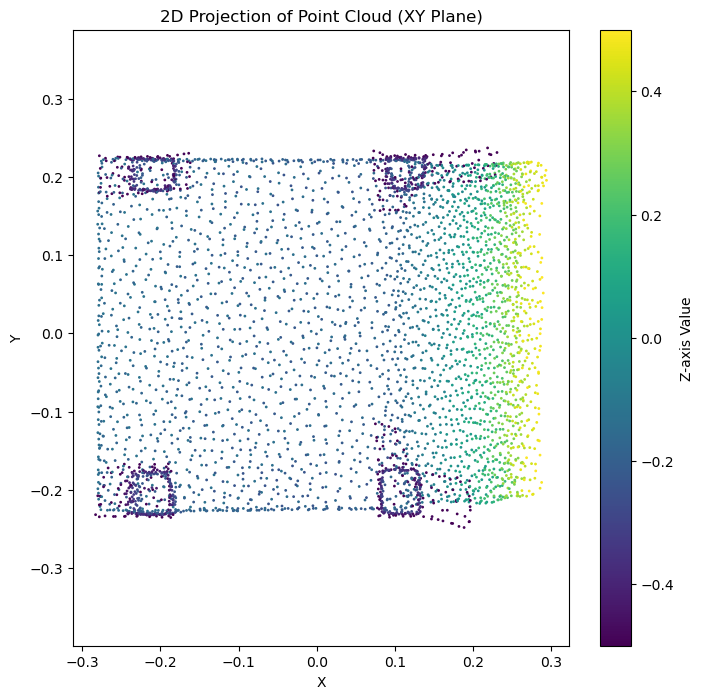

In [2]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import os


base_dir = "/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/2_Generation_Image_PointE/test_generated"
file_name = "test_sample.ply"
file_path = os.path.join(base_dir, file_name)

# Point Cloud 로드
pcd = o3d.io.read_point_cloud(file_path)
points = np.asarray(pcd.points)

# 2D 시각화 (XY Plane 기준)
plt.figure(figsize=(8, 8))
plt.scatter(points[:, 0], points[:, 1], s=1, c=points[:, 2], cmap='viridis')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Projection of Point Cloud (XY Plane)")
plt.colorbar(label='Z-axis Value')
plt.axis('equal')
plt.show()



# 🔍 Visual Comparison of Original and Augmented 3D Point Clouds

This script visualizes and compares **original vs. augmented** 3D point cloud samples from the [ModelNet40](https://modelnet.cs.princeton.edu/) dataset. The visualization is done using the [Open3D](http://www.open3d.org/) library.

---

## 🧠 Goal

To visually inspect how **data augmentation techniques** (rotation, scaling, noise, dropout, etc.) affect point cloud geometry by rendering both the original and the augmented versions side-by-side for each class.

---

## 📁 Dataset Files

The following NumPy files are expected:

| File Name                               | Shape           | Description                          |
|----------------------------------------|------------------|--------------------------------------|
| `modelnet40_sampled_data.npy`          | `(1000, 2048, 3)` | Original point clouds                |
| `modelnet40_sampled_data_augmented.npy`| `(1000, 2048, 3)` | Augmented point clouds               |
| `modelnet40_sampled_labels.npy`        | `(1000,)`        | Corresponding class labels (0~39)    |

---

## 📜 Script Features

- Iterates through all **40 classes** (ModelNet40).
- Visualizes **3 samples per class**.
- Each visualization shows:
  - 🟡 Original point cloud (in yellow)
  - 🔵 Augmented point cloud (in blue), translated to the right for comparison

---

## 🖼️ Visualization Example

Each rendered frame will show:

```

\[ Original (Yellow) ]     \[ Augmented (Blue) ]

````

---

## 🧪 Key Code Snippet

```python
pc_orig.paint_uniform_color([1, 0.706, 0])  # Yellow
pc_aug.paint_uniform_color([0, 0.651, 0.929])  # Blue
pc_aug.translate((1.0, 0, 0))  # Offset for side-by-side comparison
````

---

## ▶️ How to Run

1. Make sure Open3D and NumPy are installed:

```bash
pip install open3d numpy
```

2. Place the `.npy` files in the same folder as the script.
3. Run the script:

```bash
python visualize_pointcloud_comparison.py
```

4. Use your mouse in the Open3D window to zoom/rotate/pan and inspect the shape differences.

---

## 📌 Notes

* You can change `samples_per_class` or `num_classes` in the script for faster runs.
* This tool is useful for debugging augmentation quality before model training.
* You can also modify this script to save the views as images using `draw_geometries_with_key_callbacks()` or Open3D’s capture API.

---

## 📚 References

* [Open3D Documentation](http://www.open3d.org/docs/latest/)
* [ModelNet40 Dataset](https://modelnet.cs.princeton.edu/)

```



In [ ]:
import open3d as o3d
import numpy as np

# 🔹 Load data /ModelNet40_PointE/bathtub/bathtub_0001.ply
data_orig = np.load("modelnet40_sampled_data.npy")              # Shape: (1000, 2048, 3)
data_aug = np.load("modelnet40_sampled_data_augmented.npy")     # Shape: (1000, 2048, 3)
labels = np.load("modelnet40_sampled_labels.npy")               # Shape: (1000,)

# 🔹 Number of samples to visualize per class
samples_per_class = 3
num_classes = 40

# 🔹 Visualize original vs augmented point clouds per class
for cls in range(num_classes):
    count = 0
    for idx in range(len(labels)):
        if labels[idx] == cls:
            # Create original point cloud
            pc_orig = o3d.geometry.PointCloud()
            pc_orig.points = o3d.utility.Vector3dVector(data_orig[idx])
            pc_orig.paint_uniform_color([1, 0.706, 0])  # Yellow

            # Create augmented point cloud
            pc_aug = o3d.geometry.PointCloud()
            pc_aug.points = o3d.utility.Vector3dVector(data_aug[idx])
            pc_aug.paint_uniform_color([0, 0.651, 0.929])  # Blue
            pc_aug.translate((1.0, 0, 0))  # Shift to the right for side-by-side comparison

            print(f"📌 Visualizing class {cls} (sample {count + 1})")
            o3d.visualization.draw_geometries([pc_orig, pc_aug])

            count += 1
            if count >= samples_per_class:
                break


📌 Visualizing class 0 (sample 1)
📌 Visualizing class 0 (sample 2)
📌 Visualizing class 0 (sample 3)
📌 Visualizing class 1 (sample 1)
📌 Visualizing class 1 (sample 2)
📌 Visualizing class 1 (sample 3)
📌 Visualizing class 2 (sample 1)
📌 Visualizing class 2 (sample 2)
📌 Visualizing class 2 (sample 3)
📌 Visualizing class 3 (sample 1)
📌 Visualizing class 3 (sample 2)
📌 Visualizing class 3 (sample 3)
📌 Visualizing class 4 (sample 1)
📌 Visualizing class 4 (sample 2)
📌 Visualizing class 4 (sample 3)
📌 Visualizing class 5 (sample 1)


KeyboardInterrupt: 

In [3]:
import open3d as o3d
import numpy as np

data_orig = np.load("/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/modelnet40_sampled_data.npy")              # Shape: (1000, 2048, 3)
data_aug = np.load("/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/modelnet40_sampled_data_augmented.npy")     # Shape: (1000, 2048, 3)
labels = np.load("/Users/junseok/Desktop/Project/Course_Projects/Emerging_Topic_in_AI/modelnet40_sampled_labels.npy")               # Shape: (1000,)

# 🔹 클래스 이름과 숫자 매핑
class_names = [
    "airplane", "bathtub", "bed", "bench", "bookshelf", "bottle", "bowl", "car", "chair",
    "cone", "cup", "curtain", "desk", "door", "dresser", "flower_pot", "glass_box", "guitar",
    "keyboard", "lamp", "laptop", "mantel", "monitor", "night_stand", "person", "piano", "plant",
    "radio", "range_hood", "sink", "sofa", "stairs", "stool", "table", "tent", "toilet",
    "tv_stand", "vase", "wardrobe", "xbox"
]
target_classes = ["chair", "bench", "car"]
target_class_indices = [class_names.index(name) for name in target_classes]

# 🔹 클래스별로 3개씩 시각화
samples_per_class = 2
for cls_name, cls_idx in zip(target_classes, target_class_indices):
    count = 0
    for idx in range(len(labels)):
        if labels[idx] == cls_idx:
            # 원본 point cloud
            pc_orig = o3d.geometry.PointCloud()
            pc_orig.points = o3d.utility.Vector3dVector(data_orig[idx])
            pc_orig.paint_uniform_color([1, 0.706, 0])  # Yellow

            # 증강된 point cloud
            pc_aug = o3d.geometry.PointCloud()
            pc_aug.points = o3d.utility.Vector3dVector(data_aug[idx])
            pc_aug.paint_uniform_color([0, 0.651, 0.929])  # Blue
            pc_aug.translate((1.0, 0, 0))  # 오른쪽으로 이동

            print(f"📌 Visualizing class '{cls_name}' (sample {count + 1})")
            o3d.visualization.draw_geometries([pc_orig, pc_aug])

            count += 1
            if count >= samples_per_class:
                break


📌 Visualizing class 'chair' (sample 1)
📌 Visualizing class 'chair' (sample 2)
📌 Visualizing class 'bench' (sample 1)
📌 Visualizing class 'bench' (sample 2)
📌 Visualizing class 'car' (sample 1)
📌 Visualizing class 'car' (sample 2)
